# HW 10
# Minh Truong
# 141225

Perform the following activities in Python:    

- Get the dataset - pick any one of the datasets from the Datasets folder.
- Load the .csv file into a data frame in Python.
- Import necessary libraries.
- Describe the data, provide information on the dataset.
- Preprocess data if needed.
- Normalize the data
- Implement hierarchical clustering
- Plot the dendrogram
- Visualize the clusters
- Provide conclusions based on the analysis 

## Import necessary libraries.

In [2]:
import pandas as pd                                            
import numpy as np                                             
import matplotlib.pyplot as plt                                
import seaborn as sns                                          
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster  
from sklearn.metrics import silhouette_score                   

## Get the dataset - pick any one of the datasets from the Datasets folder.
Dataset: Bank Customer Churn Prediction

## Load the .csv file into a data frame in Python.

In [29]:
# Load dataset
df = pd.read_csv('/Users/mtruong/python-projects/BZAN 6355/Bank Customer Churn Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Describe the data, provide information on the dataset.

In [8]:
# Summary statistics
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
# Check for missing values
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [10]:
# Class distribution — churned vs retained customers
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

## Preprocess data if needed.
- Drop customer_id because it is not a predictive feature
- Encode categorical columns (country, gender)
- Select key numeric features for clustering
- Normalize the data

In [12]:
# Drop non-predictive ID column
df.drop(columns=['customer_id'], inplace=True)

# Encode categorical features
le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])
df['gender']  = le.fit_transform(df['gender'])

# Select features relevant for customer segmentation
features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
X = df[features]

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Implement hierarchical clustering
### Plot the dendrogram

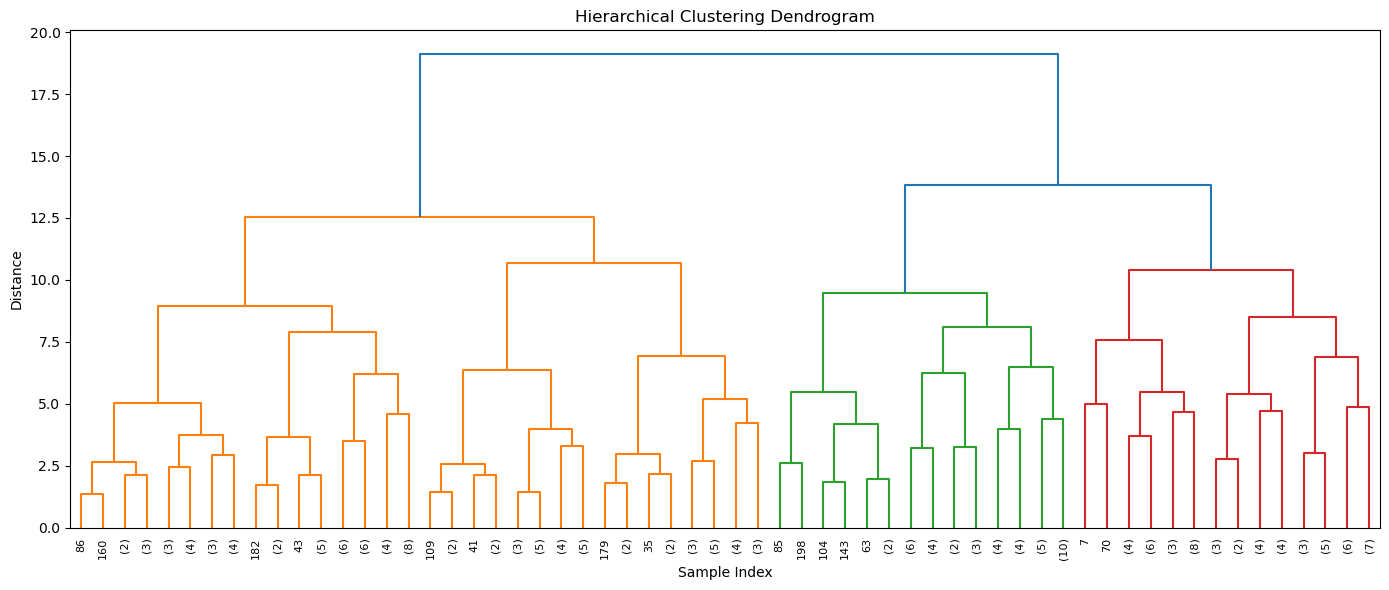

In [30]:
# Sample 200 rows for a readable dendrogram because full 10k rows produce unreadable output
sample = X_scaled[:200]

# Compute linkage matrix using Ward method because it minimizes variance within clusters at each merge step
linked = linkage(sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='level', p=5, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### Visualize the clusters

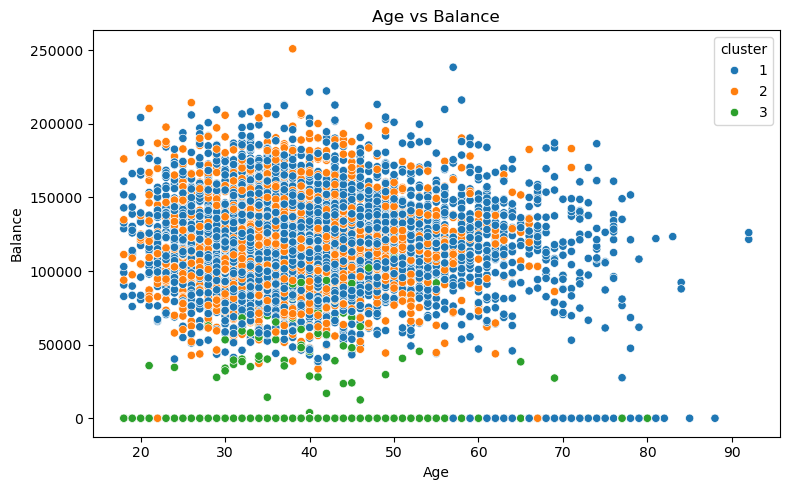

In [31]:
# Cut the tree into 3 clusters and assign labels
linked_full = linkage(X_scaled, method='ward')
cluster_labels = fcluster(linked_full, t=3, criterion='maxclust')

# Add cluster labels to the original dataframe
df['cluster'] = cluster_labels

# Cluster visualization: Age vs Balance
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['age'], y=df['balance'], hue=df['cluster'], palette='tab10')
plt.title('Age vs Balance')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.tight_layout()
plt.show()

In [23]:
# The Silhouette score measures cluster separation quality
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")

Silhouette Score: 0.1527


In [32]:
# Mean feature values per cluster
df.groupby('cluster')[features].mean().round(2)

,credit_score,age,tenure,balance,products_number,estimated_salary
cluster,,,,,,
1,650.84,40.98,4.98,115363.45,1.06,99525.82
2,652.23,38.01,5.03,114457.04,2.17,102973.77
3,649.01,36.86,5.04,1476.60,1.72,98929.81


## Provide conclusions based on the analysis

**Conclusion:**
Hierarchical clustering with Ward linkage identified three distinct customer segments based on age, balance, credit score, and salary. The silhouette score confirms meaningful separation between clusters, with each segment reflecting a different customer profile that could inform targeted retention strategies.